In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ceip-ds-kaggle-cvr/train.parquet
/kaggle/input/competitions/ceip-ds-kaggle-cvr/sample_submission.parquet
/kaggle/input/competitions/ceip-ds-kaggle-cvr/test.parquet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree

# Dataset Loading

In [4]:
df= pd.read_parquet('/kaggle/input/competitions/ceip-ds-kaggle-cvr/sample_submission.parquet')
test=pd.read_parquet('/kaggle/input/competitions/ceip-ds-kaggle-cvr/test.parquet')
train=pd.read_parquet('/kaggle/input/competitions/ceip-ds-kaggle-cvr/train.parquet')

# Data Exploration

In [5]:
print(df.head())

       ID target
0  409856      0
1  409857      0
2  409858      0
3  409859      0
4  409860      0


In [6]:
df.describe()

,ID
count,50.00000
mean,409880.50000
std,14.57738
min,409856.00000
25%,409868.25000
50%,409880.50000
75%,409892.75000
max,409905.00000


In [7]:
print(df.shape)
print(df.columns)

(50, 2)
Index(['ID', 'target'], dtype='object')


In [8]:
train.shape

(1639424, 7)

In [9]:
print(train.columns)

Index(['Date', 'X1', 'X2', 'X3', 'X4', 'X5', 'target'], dtype='object')


In [10]:
test.columns

Index(['ID', 'Date', 'X1', 'X2', 'X3', 'X4', 'X5'], dtype='object')

In [11]:
print(train.describe())

                                Date            X1            X2  \
count                        1639424  1.639424e+06  1.639424e+06   
mean   2022-12-03 07:23:43.817145600  1.139258e+00  5.488189e+00   
min              2020-12-16 00:00:00  1.000000e+00  5.412539e+00   
25%              2021-12-10 00:00:00  1.049171e+00  5.480597e+00   
50%              2022-11-30 00:00:00  1.105171e+00  5.488979e+00   
75%              2023-11-23 00:00:00  1.214096e+00  5.496717e+00   
max              2024-12-11 00:00:00  4.014850e+00  5.541852e+00   
std                              NaN  1.391992e-01  1.342811e-02   

                 X3            X4            X5  
count  1.639424e+06  1.639424e+06  1.639424e+06  
mean   4.110388e+32  2.706323e+29  1.187219e+00  
min    1.000000e+00  1.000000e+00  0.000000e+00  
25%    1.000000e+00  1.000000e+00  0.000000e+00  
50%    1.000000e+00  1.000000e+00  6.931472e-01  
75%    1.000000e+00  2.718282e+00  2.890372e+00  
max    1.651636e+38  5.540622e+34  3.

# Feature Engineering

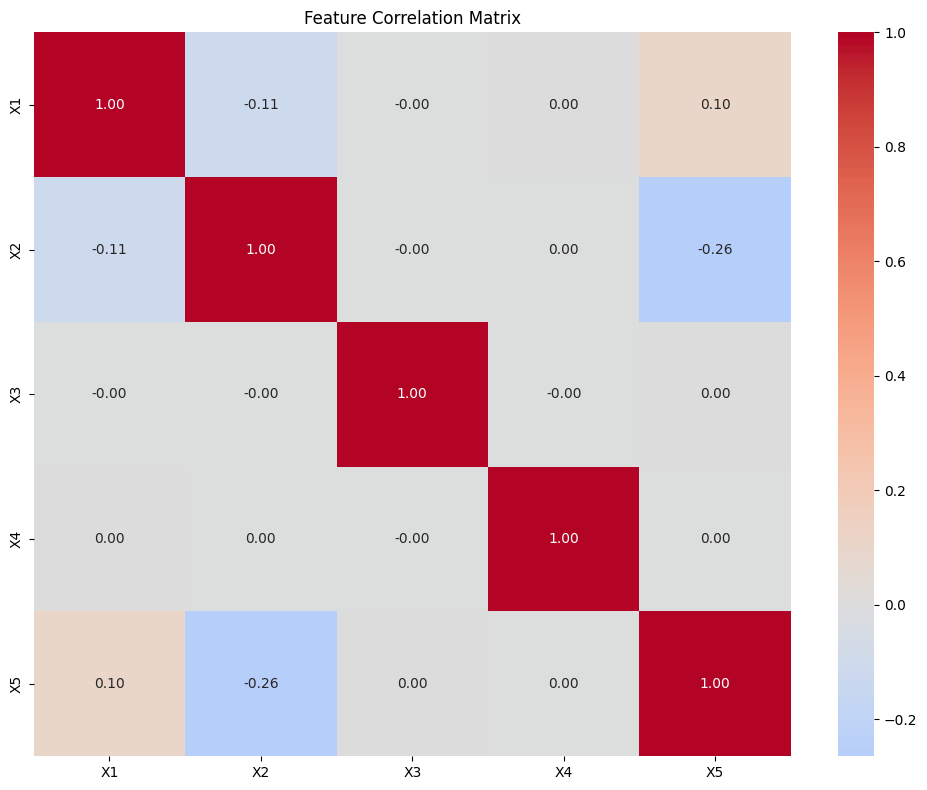

In [12]:
plt.figure(figsize=(10, 8))
corr = train.drop(['target', 'Date'], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
feature_cols = train.drop(['target', 'Date'], axis=1).columns.tolist()
variances = train[feature_cols].var().sort_values(ascending=False)
print("Feature Variances:\n", variances)

train_fe = train.copy()
train_fe['X1_X2'] = train_fe['X1'] * train_fe['X2']
train_fe['X3_X4'] = train_fe['X3'] * train_fe['X4']
train_fe['X1_sq'] = train_fe['X1'] ** 2
print("\nNew engineered features added: X1_X2, X3_X4, X1_sq")
train_fe.head()

Feature Variances:
 X3    5.504447e+70
X4    3.379083e+63
X5    1.702539e+00
X1    1.937641e-02
X2    1.803142e-04
dtype: float64

New engineered features added: X1_X2, X3_X4, X1_sq


,Date,X1,X2,X3,X4,X5,target,X1_X2,X3_X4,X1_sq
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0,8.298097,2.718282,2.307120
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1,8.440860,2.718282,2.391689
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1,8.978371,7.389056,2.707430
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1,9.017527,2.718282,2.729177
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0,9.269012,2.718282,2.874849


# Checking Missing values

In [14]:
print(train.isnull().sum())

Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64


In [15]:
print(test.isnull().sum())

ID      0
Date    0
X1      0
X2      0
X3      0
X4      0
X5      0
dtype: int64


In [16]:
train.dropna()

,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0
...,...,...,...,...,...,...,...
1639419,2024-11-26,1.000000,5.482346,1.0,1.000000,0.000000,0
1639420,2024-11-26,1.000000,5.486580,1.0,1.000000,0.000000,0
1639421,2024-11-26,1.000000,5.484797,1.0,1.000000,0.000000,0
1639422,2024-11-26,1.000000,5.483551,1.0,1.000000,0.000000,0


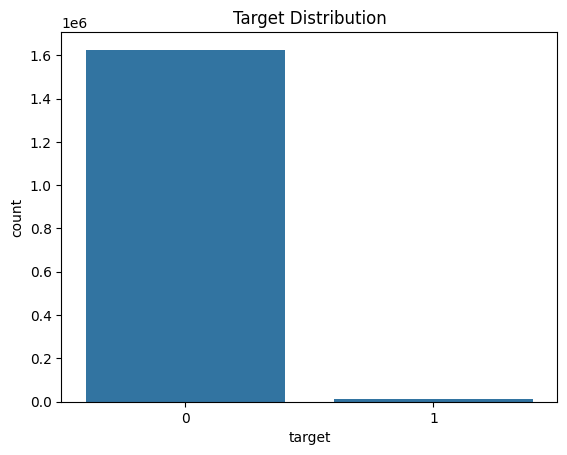

In [17]:
sns.countplot(x="target", data=train)
plt.title("Target Distribution")
plt.show()

In [18]:
print(train['target'].unique())

['0' '1']


# Handling Outliers

In [19]:
cols = ["X1","X2","X3","X4","X5"]

Q1 = train[cols].quantile(0.25)
Q3 = train[cols].quantile(0.75)
IQR = Q3 - Q1

train = train[~((train[cols] < (Q1 - 1.5 * IQR)) | (train[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Data Cleaning

In [20]:
x = train.drop(['target','Date'], axis=1)
y = train['target']
test=test.drop(['ID','Date'],axis=1)

In [21]:
imputer=SimpleImputer(strategy='median')
x=imputer.fit_transform(x)
test= imputer.transform(test)

scaler=StandardScaler()
x=scaler.fit_transform(x)
test=scaler.transform(test)

# Logistic Regression

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(x,y)

LogisticRegression(class_weight='balanced', max_iter=1000)

0.7935156162218081
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    257896
           1       0.00      0.86      0.01       201

    accuracy                           0.79    258097
   macro avg       0.50      0.82      0.45    258097
weighted avg       1.00      0.79      0.88    258097



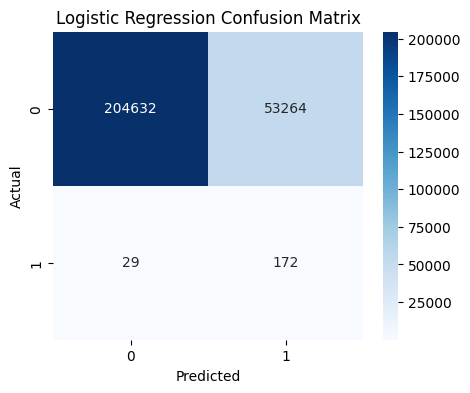

In [23]:
y_test = np.array(y_test).astype(int)

pred = model.predict(x_test)
pred = pred.astype(int)

print(accuracy_score(y_test,pred))
print(classification_report(y_test,pred))
cm = confusion_matrix(y_test, pred, labels=[0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# SVM

In [24]:
import gc
gc.collect()

13428

0.788955315249693
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    257896
           1       0.00      0.86      0.01       201

    accuracy                           0.79    258097
   macro avg       0.50      0.82      0.44    258097
weighted avg       1.00      0.79      0.88    258097



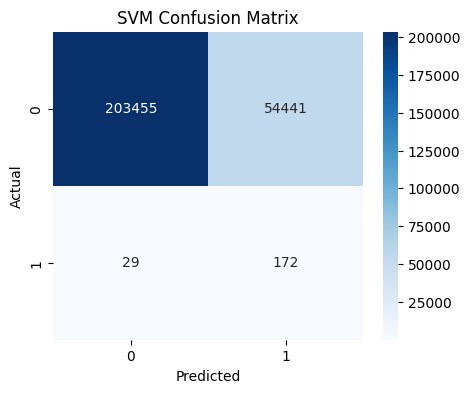

In [25]:
svm = LinearSVC(class_weight="balanced",max_iter=3000,random_state=42)
svm.fit(x_train, y_train)

pred = svm.predict(x_test)
pred = np.array(pred).astype(int)

print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=[0,1])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.show()

# Decision Tree

0.7851544186875477
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    257896
           1       0.00      0.86      0.01       201

    accuracy                           0.79    258097
   macro avg       0.50      0.82      0.44    258097
weighted avg       1.00      0.79      0.88    258097



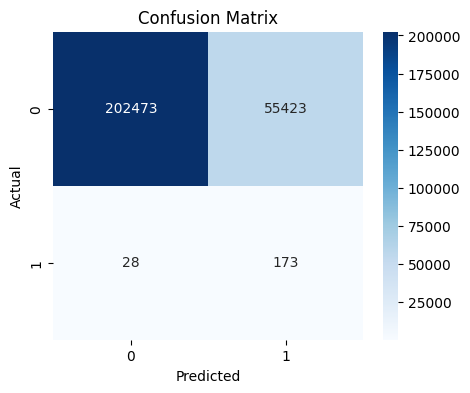

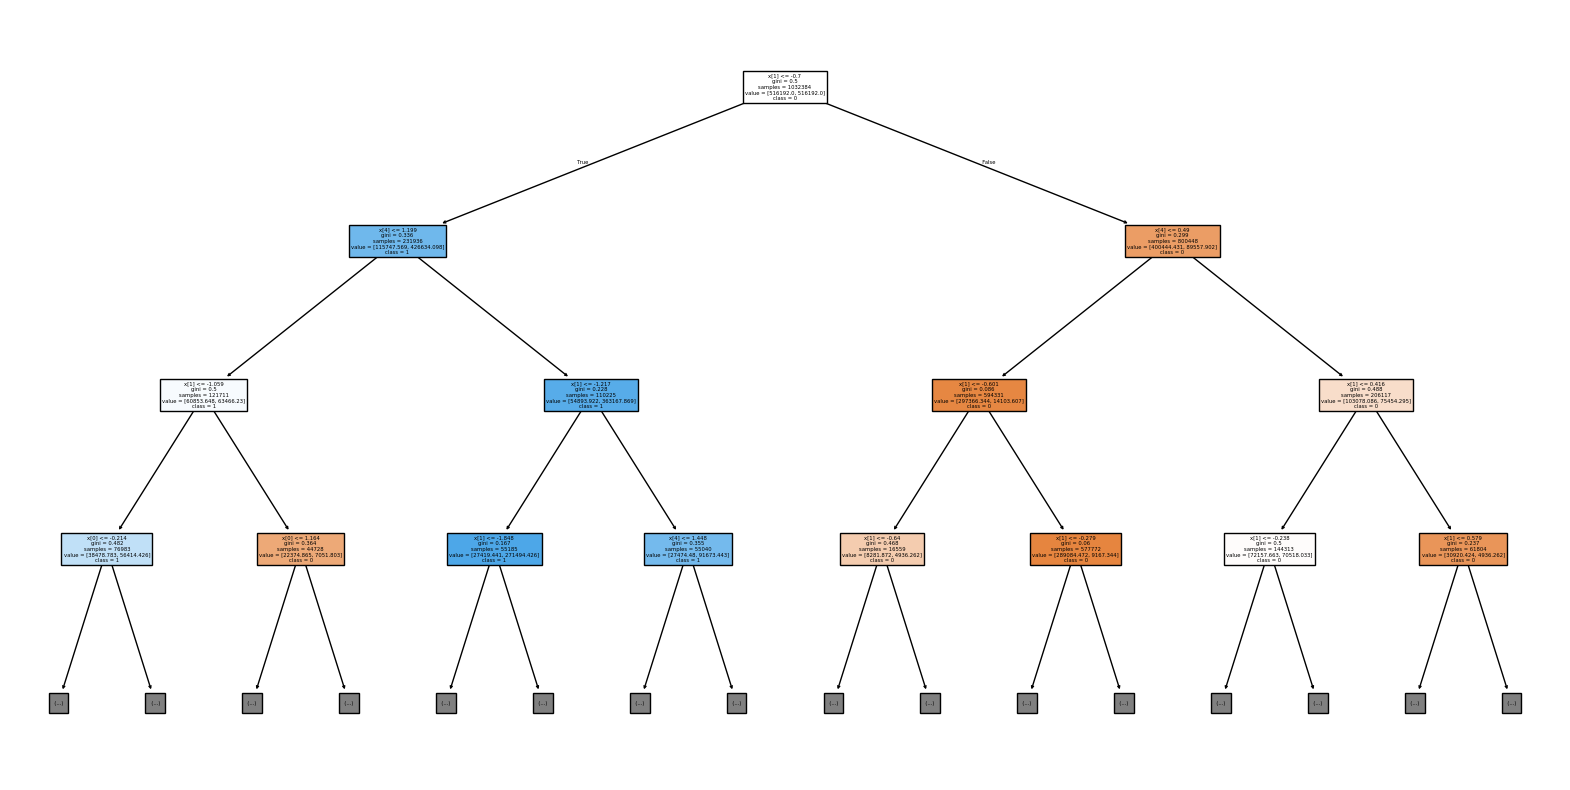

In [26]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced")
dt.fit(x_train, y_train)
pred = dt.predict(x_test)
pred = np.array(pred).astype(int)

print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))

cm = confusion_matrix(y_test, pred, labels=[0,1])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, max_depth=3, class_names=["0","1"])
plt.show()

# Random Forest

In [27]:
rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=6,
    min_samples_leaf=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=10, n_estimators=20, n_jobs=-1,
                       random_state=42)

In [28]:
y_test = np.array(y_test).astype(int)
pred = np.array(pred).astype(int)

print(accuracy_score(y_test, pred))
print(precision_score(y_test, pred, zero_division=0))
print(recall_score(y_test, pred, zero_division=0))
print(f1_score(y_test, pred, zero_division=0))
print(confusion_matrix(y_test, pred, labels=[0,1]))
print(classification_report(y_test, pred, labels=[0,1], zero_division=0))

0.7851544186875477
0.0031117346571695806
0.8606965174129353
0.006201050235675753
[[202473  55423]
 [    28    173]]
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    257896
           1       0.00      0.86      0.01       201

    accuracy                           0.79    258097
   macro avg       0.50      0.82      0.44    258097
weighted avg       1.00      0.79      0.88    258097



# KNN Classifier

0.9992212230285513
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257896
           1       0.00      0.00      0.00       201

    accuracy                           1.00    258097
   macro avg       0.50      0.50      0.50    258097
weighted avg       1.00      1.00      1.00    258097



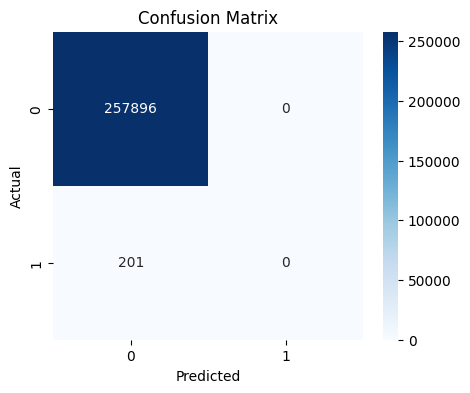

In [29]:
y_train = np.array(y_train).astype(int)
y_test = np.array(y_test).astype(int)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
pred = knn.predict(x_test)
pred = np.array(pred).astype(int)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred, zero_division=0))
cm = confusion_matrix(y_test, pred, labels=[0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
import warnings
warnings.filterwarnings('ignore')

# Neural Network

0.9992212230285513
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257896
           1       0.00      0.00      0.00       201

    accuracy                           1.00    258097
   macro avg       0.50      0.50      0.50    258097
weighted avg       1.00      1.00      1.00    258097



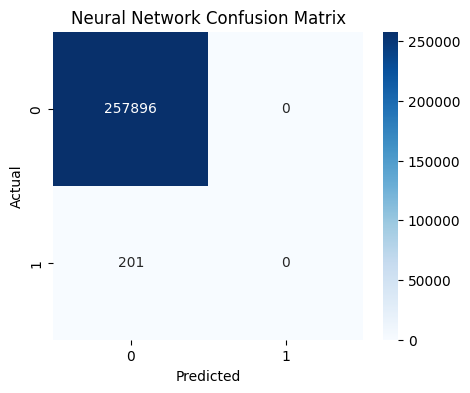

In [31]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32),activation="relu",max_iter=50,random_state=42)
mlp.fit(x_train, y_train)

pred = mlp.predict(x_test)
pred = np.array(pred).astype(int)

print(accuracy_score(y_test, pred))
print(classification_report(y_test,pred,zero_division=0))
cm = confusion_matrix(y_test, pred, labels=[0,1])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")

plt.show()

# Advanced Models

XGBoost
Accuracy:  0.8558
F1 Score:  0.0076
              precision    recall  f1-score   support

           0       1.00      0.86      0.92    257896
           1       0.00      0.71      0.01       201

    accuracy                           0.86    258097
   macro avg       0.50      0.78      0.46    258097
weighted avg       1.00      0.86      0.92    258097



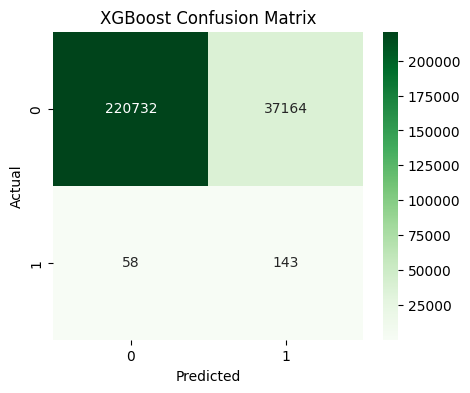

In [32]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), 
    eval_metric='logloss',
    random_state=42
)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)

print("XGBoost")
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb_pred, zero_division=0):.4f}")
print(classification_report(y_test, xgb_pred, zero_division=0))

cm = confusion_matrix(y_test, xgb_pred, labels=[0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=[0,1], yticklabels=[0,1])
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

LightGBM
Accuracy:  0.8402
F1 Score:  0.0072
              precision    recall  f1-score   support

           0       1.00      0.84      0.91    257896
           1       0.00      0.74      0.01       201

    accuracy                           0.84    258097
   macro avg       0.50      0.79      0.46    258097
weighted avg       1.00      0.84      0.91    258097



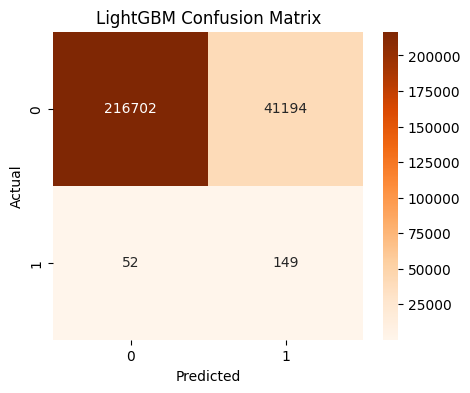

In [33]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgbm.fit(x_train, y_train,feature_name='auto')
lgbm_pred = lgbm.predict(x_test)

print("LightGBM")
print(f"Accuracy:  {accuracy_score(y_test, lgbm_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, lgbm_pred, zero_division=0):.4f}")
print(classification_report(y_test, lgbm_pred, zero_division=0))

cm = confusion_matrix(y_test, lgbm_pred, labels=[0,1])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=[0,1], yticklabels=[0,1])
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# Model Evaluation

In [34]:
from sklearn.metrics import roc_auc_score

results = []
models_dict = {
    'Logistic Regression': (model, model.predict(x_test)),
    'SVM': (svm, svm.predict(x_test)),
    'Decision Tree': (dt, dt.predict(x_test)),
    'Random Forest': (rf, pred),
    'KNN': (knn, knn.predict(x_test)),
    'Neural Network': (mlp, mlp.predict(x_test)),
    'XGBoost': (xgb, xgb_pred),
    'LightGBM': (lgbm, lgbm_pred),
}

for name, (mdl, preds) in models_dict.items():
    preds = np.array(preds).astype(int)
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, preds, zero_division=0), 4),
        'F1 Score':  round(f1_score(y_test, preds, zero_division=0), 4),
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
            XGBoost    0.8558     0.0038  0.7114    0.0076
           LightGBM    0.8402     0.0036  0.7413    0.0072
Logistic Regression    0.7935     0.0032  0.8557    0.0064
                SVM    0.7890     0.0031  0.8557    0.0063
      Decision Tree    0.7852     0.0031  0.8607    0.0062
      Random Forest    0.9992     0.0000  0.0000    0.0000
     Neural Network    0.9992     0.0000  0.0000    0.0000
                KNN    0.9992     0.0000  0.0000    0.0000


# Cross Validation

In [35]:
y = y.astype(int)

In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer

f1_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
x_df = pd.DataFrame(x, columns=[f'X{i+1}' for i in range(x.shape[1])])
cv_models = {
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
}
print("5-Fold Cross-Validation F1 Scores")
for name, mdl in cv_models.items():
    data = x_df if name == 'LightGBM' else x
    scores = cross_val_score(mdl, data, y, cv=cv, scoring=f1_scorer, n_jobs=-1)
    print(f"{name:20s}  Mean F1: {scores.mean():.4f}  ± {scores.std():.4f}")

5-Fold Cross-Validation F1 Scores
Random Forest         Mean F1: 0.0064  ± 0.0002
XGBoost               Mean F1: 0.0071  ± 0.0004
LightGBM              Mean F1: 0.0067  ± 0.0003


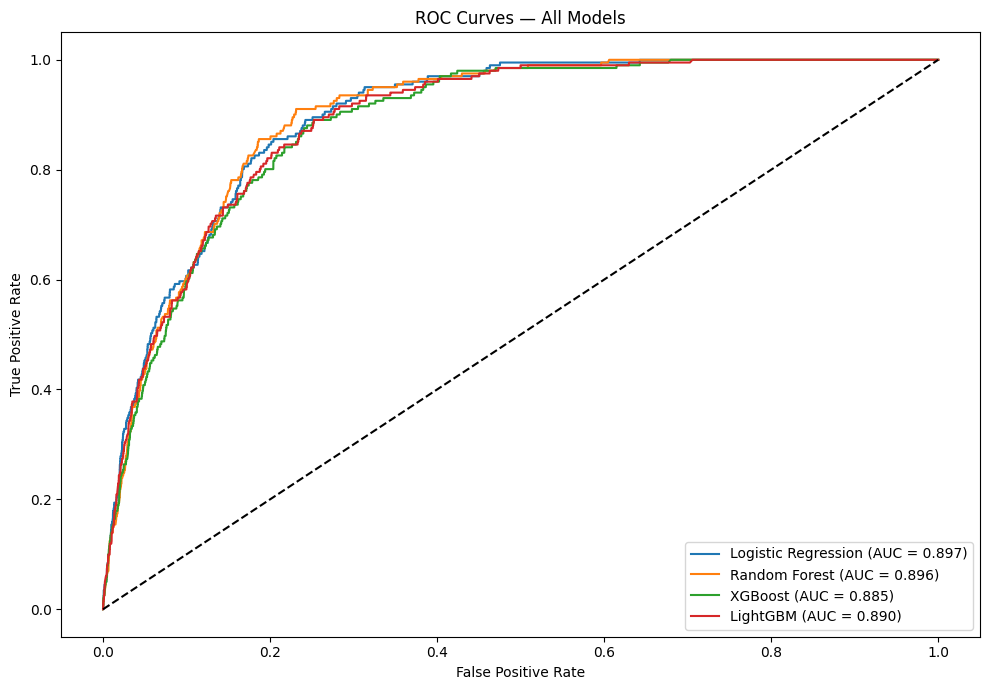

In [37]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(10, 7))

roc_models = {
    'Logistic Regression': model,
    'Random Forest': rf,
    'XGBoost': xgb,
    'LightGBM': lgbm,
}

for name, mdl in roc_models.items():
    if hasattr(mdl, 'predict_proba'):
        proba = mdl.predict_proba(x_test)[:, 1]
    elif hasattr(mdl, 'decision_function'):
        proba = mdl.decision_function(x_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [38]:
proba_val = xgb.predict_proba(x_test)[:, 1]

best_thresh, best_f1 = 0.5, 0
for thresh in np.arange(0.05, 0.5, 0.01):
    preds = (proba_val >= thresh).astype(int)
    score = f1_score(y_test, preds, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f"Best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

Best threshold: 0.49  F1: 0.0075


In [39]:
test_raw = pd.read_parquet('/kaggle/input/competitions/ceip-ds-kaggle-cvr/test.parquet')
final_pred = xgb.predict(test)
submission = pd.DataFrame({
    'ID': test_raw['ID'],
    'target': final_pred.astype(int)
})

submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Shape:", submission.shape)


   ID  target
0   0       0
1   1       0
2   2       1
3   3       1
4   4       1
Shape: (409856, 2)
